# Silver layer - build the canonical analysis tables

Transforms every bronze record into two tidy tables via each engine's `adapter.normalise()`:

- **responses** - one row per (engine, query, run): answer text, length, citation counts, provenance -> feeds SIS, CV
- **citations** - one row per cited source: url, canonical url, domain, provenance -> feeds PAWC, AIS

Runs **offline** (no API keys/calls) - silver is a pure transform on the immutable bronze.

In [1]:
# robust path shim: find project root (folder containing thesis_config.py)
import sys
from pathlib import Path
p = Path.cwd()
while not (p / "thesis_config.py").exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p))

import pandas as pd
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)

import thesis_config as cfg
from src import silver
print(cfg.profile_summary())
print("bronze dir:", cfg.BRONZE)
print("silver dir:", cfg.SILVER)

RUN PROFILE: PILOT  (N=100, K=3, root=/Users/ganenthraravindran/Desktop/Thesis Data Pilot/data/pilot)
bronze dir: /Users/ganenthraravindran/Desktop/Thesis Data Pilot/data/pilot/bronze
silver dir: /Users/ganenthraravindran/Desktop/Thesis Data Pilot/data/pilot/silver


## 1. Build silver from bronze
Reads every bronze JSON, normalises via adapters, writes two parquet tables to `data/<profile>/silver/`.

In [2]:
responses, citations, report = silver.build_silver(write=True)
print("BUILD REPORT")
for k, v in report.items():
    if k != "failures":
        print(f"  {k}: {v}")
print(f"  failures: {len(report['failures'])}")
for f in report["failures"][:10]:
    print("   ", f)

BUILD REPORT
  bronze_records: 1582
  normalised: 1582
  profiles: ['pilot']
  n_responses_rows: 1582
  n_citations_rows: 8827
  failures: 0


## 2. Per-engine coverage
Expecting ~300 cells per fully-collected engine (100 queries x k=3). Mistral is known-partial.

In [3]:
cov = (responses.groupby("engine")
       .agg(cells=("query_id", "count"), queries=("query_id", "nunique"))
       .reset_index())
cov["expected_cells"] = cfg.N_QUERIES * cfg.K
cov["mean_runs_per_query"] = (cov["cells"] / cov["queries"]).round(2)
cov["coverage_pct"] = (100 * cov["cells"] / cov["expected_cells"]).round(1)
display(cov)

# queries with fewer than k runs, per engine (incompleteness)
rpq = responses.groupby(["engine", "query_id"]).size().reset_index(name="n_runs")
incomplete = (rpq[rpq.n_runs < cfg.K].groupby("engine").size()
              .reset_index(name="queries_with_<k_runs"))
print("Queries with fewer than k =", cfg.K, "runs:")
display(incomplete if len(incomplete) else "none - all engines complete")

,engine,cells,queries,expected_cells,mean_runs_per_query,coverage_pct
0,chatgpt,300,100,300,3.00,100.0
1,claude,300,100,300,3.00,100.0
2,gemini,300,100,300,3.00,100.0
3,kimi,300,100,300,3.00,100.0
4,mistral,82,28,300,2.93,27.3
5,perplexity,300,100,300,3.00,100.0


Queries with fewer than k = 3 runs:


,engine,queries_with_<k_runs
0,mistral,1


## 3. Citation provenance breakdown
Confirms Kimi = `self_reported_prompt_elicited`; the other engines = `provider_certified`.

In [4]:
display(citations.groupby(["engine", "provenance"]).size().reset_index(name="cited_sources"))

,engine,provenance,cited_sources
0,chatgpt,provider_certified,243
1,claude,provider_certified,1477
2,gemini,provider_certified,2105
3,kimi,self_reported_prompt_elicited,2805
4,mistral,provider_certified,63
5,perplexity,provider_certified,2134


## 4. Citation-count distribution per engine
Mean cited sources per response, by engine - a first visibility signal.

,mean,median,max,min
engine,,,,
chatgpt,0.81,0.0,10,0
claude,4.92,5.0,17,0
gemini,7.02,7.0,24,0
kimi,9.35,9.0,24,0
mistral,0.77,0.0,6,0
perplexity,7.11,7.0,10,1


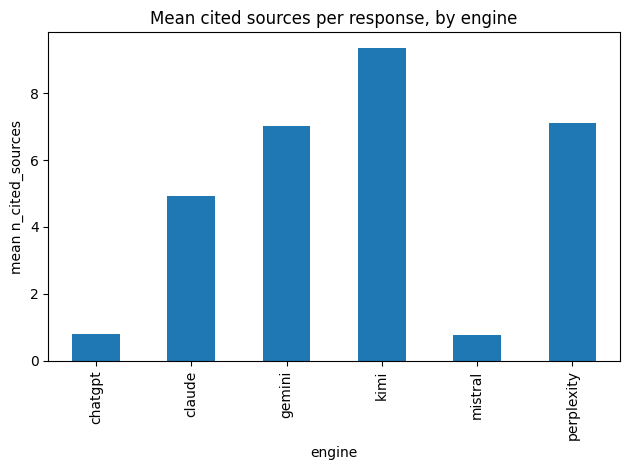

In [5]:
import matplotlib.pyplot as plt
agg = (responses.groupby("engine")["n_cited_sources"]
       .agg(["mean", "median", "max", "min"]).round(2))
display(agg)
ax = agg["mean"].plot(kind="bar", title="Mean cited sources per response, by engine")
ax.set_ylabel("mean n_cited_sources"); ax.set_xlabel("engine")
plt.tight_layout(); plt.show()

## 5. Sanity peeks
A few rows of each table, and a check for empty answers.

In [6]:
print("RESPONSES sample:")
display(responses.drop(columns=["answer_text"]).head(8))
print("CITATIONS sample:")
display(citations.head(8))
empty = responses[responses.answer_char_len == 0]
print(f"Rows with EMPTY answer_text: {len(empty)}")
if len(empty):
    display(empty[["engine", "query_id", "run_index"]].head())

RESPONSES sample:


,query_id,engine,run_index,model_served,timestamp_utc,run_profile,answer_char_len,answer_word_count,n_cited_sources,n_unique_domains,has_citations,citation_provenance
0,gb_021e53327e1ee5a9,chatgpt,1,gpt-5.5-2026-04-23,2026-05-31T18:27:37.450278+00:00,pilot,1012,160,0,0,False,
1,gb_021e53327e1ee5a9,chatgpt,2,gpt-5.5-2026-04-23,2026-05-31T18:27:43.946417+00:00,pilot,976,154,0,0,False,
2,gb_021e53327e1ee5a9,chatgpt,3,gpt-5.5-2026-04-23,2026-05-31T18:27:53.380750+00:00,pilot,1337,191,0,0,False,
3,gb_05118b5a6fcf8e43,chatgpt,1,gpt-5.5-2026-04-23,2026-05-31T18:28:40.620999+00:00,pilot,3347,365,8,8,True,provider_certified
4,gb_05118b5a6fcf8e43,chatgpt,2,gpt-5.5-2026-04-23,2026-05-31T18:28:57.521148+00:00,pilot,2583,295,5,4,True,provider_certified
5,gb_05118b5a6fcf8e43,chatgpt,3,gpt-5.5-2026-04-23,2026-05-31T18:29:18.078061+00:00,pilot,4234,414,9,8,True,provider_certified
6,gb_060a64ae9d5485dc,chatgpt,1,gpt-5.5-2026-04-23,2026-05-31T18:39:18.123487+00:00,pilot,463,74,0,0,False,
7,gb_060a64ae9d5485dc,chatgpt,2,gpt-5.5-2026-04-23,2026-05-31T18:39:24.226587+00:00,pilot,486,85,0,0,False,


CITATIONS sample:


,query_id,engine,run_index,position,url,url_canonical,domain,title,provenance
0,gb_05118b5a6fcf8e43,chatgpt,1,1,https://fashionista.com/2023/01/louis-vuitton-yayoi-kusama-collaboration-col...,https://fashionista.com/2023/01/louis-vuitton-yayoi-kusama-collaboration-col...,fashionista.com,"A Decade Later, Louis Vuitton and Yayoi Kusama Reunite - Fashionista",provider_certified
1,gb_05118b5a6fcf8e43,chatgpt,1,2,https://www.hublot.com/en-us/news/hublot-murakami-13-unique-watches-and-nfts...,https://www.hublot.com/en-us/news/hublot-murakami-13-unique-watches-and-nfts,www.hublot.com,HUBLOT AND TAKASHI MURAKAMI LAUNCH A COLLECTION OF 13 UNIQUE WATCHES AND 13 ...,provider_certified
2,gb_05118b5a6fcf8e43,chatgpt,1,3,https://www.ikea.com/us/en/newsroom/range-news/ikea-and-sabine-marcelis-laun...,https://www.ikea.com/us/en/newsroom/range-news/ikea-and-sabine-marcelis-laun...,www.ikea.com,IKEA and Sabine Marcelis introduce VARMBLIXT - IKEA,provider_certified
3,gb_05118b5a6fcf8e43,chatgpt,1,4,https://www.vogue.com/article/2023-photovogue-digital-art-collection-voice?u...,https://www.vogue.com/article/2023-photovogue-digital-art-collection-voice,www.vogue.com,2023 PhotoVogue Digital Art Collection,provider_certified
4,gb_05118b5a6fcf8e43,chatgpt,1,5,https://www.phillipscollection.org/press/linling-lus-soundwaves-phillipss-20...,https://www.phillipscollection.org/press/linling-lus-soundwaves-phillipss-20...,www.phillipscollection.org,Linling Lu’s Soundwaves is the Phillips’s 2023 Spring Intersections project ...,provider_certified
5,gb_05118b5a6fcf8e43,chatgpt,1,6,https://www.ebony.com/coca-cola-zero-sugar-art-basel-2023/?utm_source=openai,https://www.ebony.com/coca-cola-zero-sugar-art-basel-2023,www.ebony.com,Art Basel Miami 2023: EBONY FWD & Coca-Cola Zero Sugar,provider_certified
6,gb_05118b5a6fcf8e43,chatgpt,1,7,https://newsroom.ucla.edu/releases/artist-lineup-made-in-la-2023-hammer-muse...,https://newsroom.ucla.edu/releases/artist-lineup-made-in-la-2023-hammer-museum,newsroom.ucla.edu,Artist lineup set for ‘Made in L.A. 2023’ at Hammer Museum | UCLA,provider_certified
7,gb_05118b5a6fcf8e43,chatgpt,1,8,https://arxiv.org/abs/2306.03753?utm_source=openai,https://arxiv.org/abs/2306.03753,arxiv.org,AI Art Curation: Re-imagining the city of Helsinki in occasion of its Biennial,provider_certified


Rows with EMPTY answer_text: 1


,engine,query_id,run_index
702,gemini,gb_57e198d356ad745f,1


## 6. Written outputs
Silver parquet files are now in `data/<profile>/silver/`. Next: the **gold** layer (PAWC, AIS, CV, and SIS if retained).

In [7]:
for f in sorted(cfg.SILVER.glob("*.parquet")):
    print(f.name, "-", f.stat().st_size, "bytes")

citations_pilot.parquet - 1200344 bytes
responses_pilot.parquet - 2201052 bytes
